===== DATA PENELITIAN BERHASIL DI-LOAD =====
Total Sampel (N) : 136 baris data
   Tahun        Provinsi  Kepadatan Penduduk  Jumlah Kendaraan
0   2025            Aceh                  99           2898834
1   2025  Sumatera Utara                 218           8385863
2   2025  Sumatera Barat                 140           3110612
3   2025            Riau                  76           5023558
4   2025           Jambi                  77           2996472


===== STATISTIK DESKRIPTIF =====
                       Kepadatan Penduduk  Jumlah Kendaraan
Mean (Rata-rata)               750.529412      4.749830e+06
Median (Nilai Tengah)          103.000000      2.713610e+06
Modus                           10.000000      1.890910e+05
Standar Deviasi               2708.574005      6.667161e+06
Nilai Minimum                   10.000000      1.890910e+05
Nilai Maksimum               16155.000000      2.805756e+07


===== UJI NORMALITAS (KOLMOGOROV-SMIRNOV) =====
D hitung (D_max)    : 0.2832
D kritis 

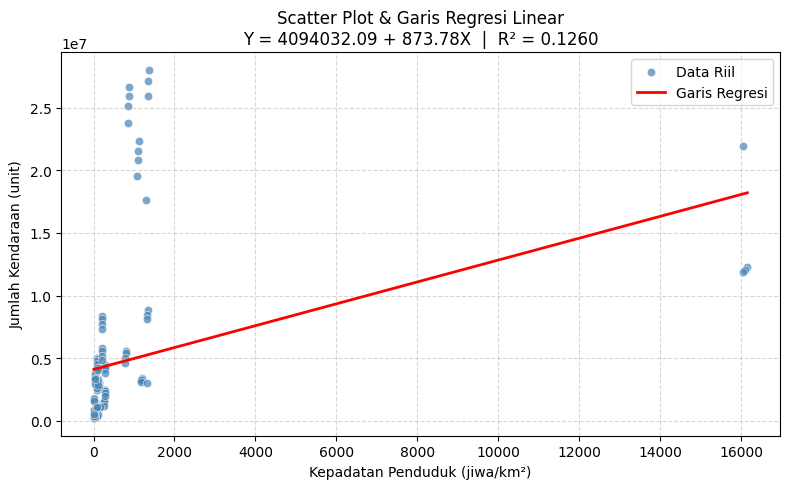

===== BOXPLOT =====


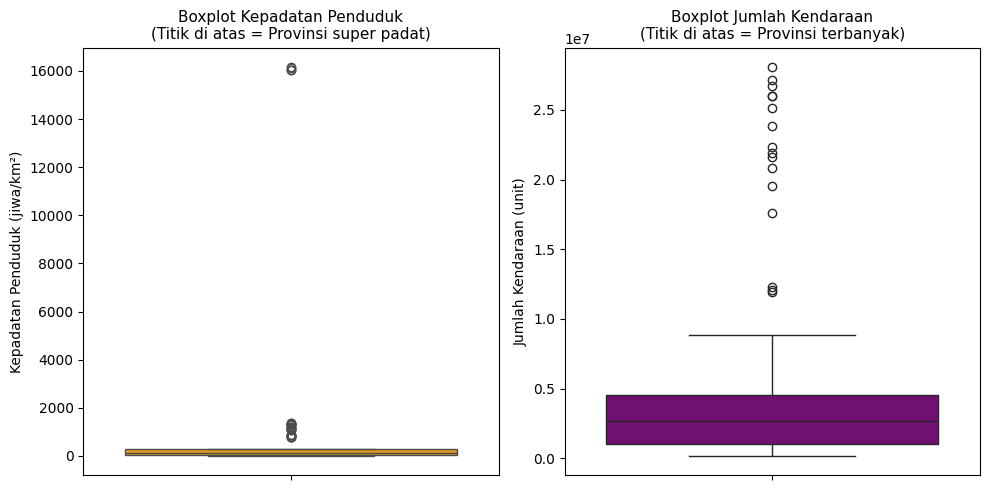

===== Q-Q PLOT RESIDUAL =====


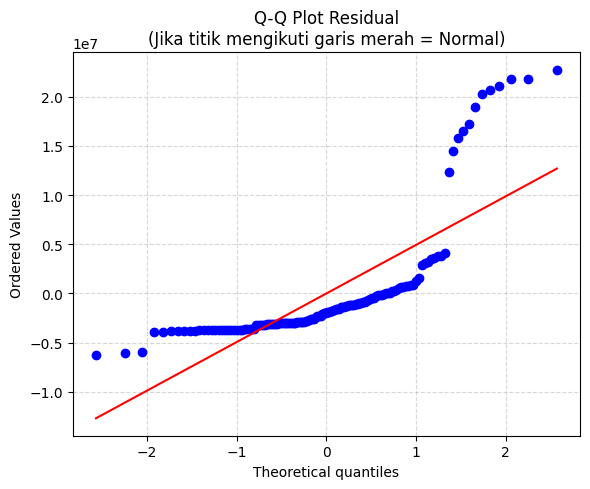

===== DIAGRAM BATANG - TOP 10 PROVINSI =====


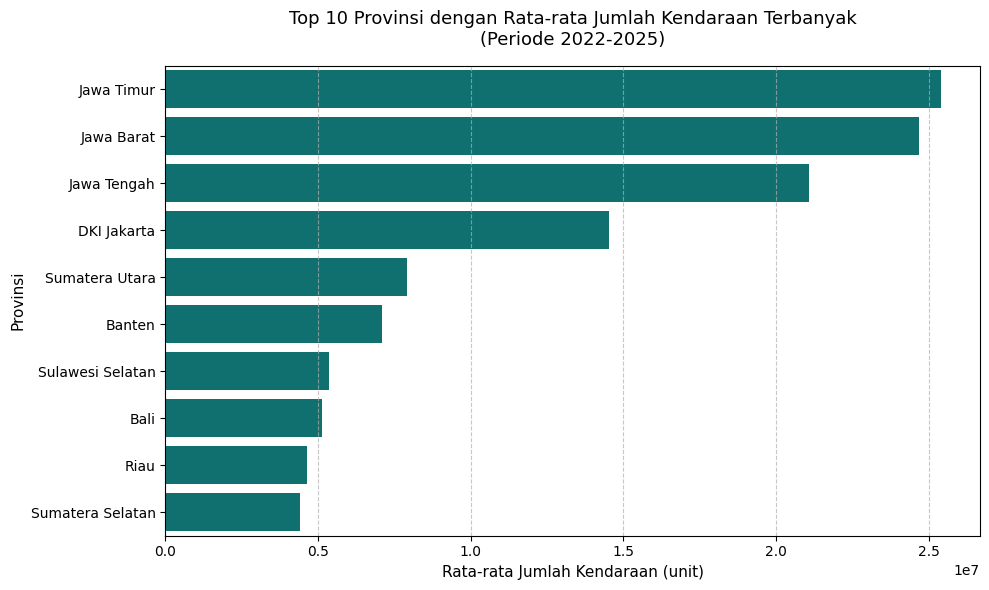

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import io

# ==========================================
# 1. LOAD DATASET
# ==========================================

data_raw = """No,Tahun,Provinsi,Kepadatan Penduduk,Jumlah Kendaraan
1,2025,Aceh,99,2898834
2,2025,Sumatera Utara,218,8385863
3,2025,Sumatera Barat,140,3110612
4,2025,Riau,76,5023558
5,2025,Jambi,77,2996472
6,2025,Sumatera Selatan,103,4936708
7,2025,Bengkulu,106,1320711
8,2025,Lampung,284,4430258
9,2025,Kepulauan Bangka Belitung,93,1280783
10,2025,Kepulauan Riau,268,1687108
11,2025,DKI Jakarta,16155,12279050
12,2025,Jawa Barat,1370,28057560
13,2025,Jawa Tengah,1113,22320623
14,2025,DI Yogyakarta,1193,3435031
15,2025,Jawa Timur,878,26699475
16,2025,Banten,1341,8832646
17,2025,Bali,798,5537916
18,2025,Nusa Tenggara Barat,291,2479997
19,2025,Nusa Tenggara Timur,124,1220053
20,2025,Kalimantan Barat,39,3523496
21,2025,Kalimantan Tengah,19,1552948
22,2025,Kalimantan Selatan,115,3359931
23,2025,Kalimantan Timur,34,3817633
24,2025,Kalimantan Utara,11,411648
25,2025,Sulawesi Utara,155,1262434
26,2025,Sulawesi Tengah,51,1090103
27,2025,Sulawesi Selatan,211,5835308
28,2025,Sulawesi Tenggara,70,1330445
29,2025,Gorontalo,103,601327
30,2025,Sulawesi Barat,92,497406
31,2025,Maluku,43,445888
32,2025,Maluku Utara,42,414924
33,2025,Papua Barat,10,203160
34,2025,Papua,13,513393
35,2024,Aceh,98,2770328
36,2024,Sumatera Utara,215,8137094
37,2024,Sumatera Barat,138,3030850
38,2024,Riau,75,4785158
39,2024,Jambi,76,2947874
40,2024,Sumatera Selatan,102,4410213
41,2024,Bengkulu,105,1260200
42,2024,Lampung,281,4263734
43,2024,Kepulauan Bangka Belitung,92,1247119
44,2024,Kepulauan Riau,264,1583019
45,2024,DKI Jakarta,16105,12057335
46,2024,Jawa Barat,1350,27104624
47,2024,Jawa Tengah,1104,21581050
48,2024,DI Yogyakarta,1186,3340248
49,2024,Jawa Timur,870,25959164
50,2024,Banten,1329,8478705
51,2024,Bali,790,5377566
52,2024,Nusa Tenggara Barat,287,2393808
53,2024,Nusa Tenggara Timur,122,1150713
54,2024,Kalimantan Barat,39,3301058
55,2024,Kalimantan Tengah,18,1787508
56,2024,Kalimantan Selatan,113,3213107
57,2024,Kalimantan Timur,33,3625843
58,2024,Kalimantan Utara,11,395107
59,2024,Sulawesi Utara,153,1194850
60,2024,Sulawesi Tengah,51,1041598
61,2024,Sulawesi Selatan,208,5584039
62,2024,Sulawesi Tenggara,67,1241435
63,2024,Gorontalo,102,568340
64,2024,Sulawesi Barat,91,481011
65,2024,Maluku,42,414758
66,2024,Maluku Utara,41,401453
67,2024,Papua Barat,10,411036
68,2024,Papua,13,870108
69,2023,Aceh,96,2623320
70,2023,Sumatera Utara,212,7756351
71,2023,Sumatera Barat,137,2877202
72,2023,Riau,74,4543634
73,2023,Jambi,75,2800030
74,2023,Sumatera Selatan,101,4234471
75,2023,Bengkulu,104,1204786
76,2023,Lampung,277,4126158
77,2023,Kepulauan Bangka Belitung,91,1210570
78,2023,Kepulauan Riau,260,1488440
79,2023,DKI Jakarta,16046,11898774
80,2023,Jawa Barat,1340,25954682
81,2023,Jawa Tengah,1093,20837197
82,2023,DI Yogyakarta,1178,3222315
83,2023,Jawa Timur,863,25150237
84,2023,Banten,1318,8135239
85,2023,Bali,783,5012858
86,2023,Nusa Tenggara Barat,283,2202391
87,2023,Nusa Tenggara Timur,120,1043777
88,2023,Kalimantan Barat,38,3133335
89,2023,Kalimantan Tengah,18,1695248
90,2023,Kalimantan Selatan,114,3078801
91,2023,Kalimantan Timur,33,3433250
92,2023,Kalimantan Utara,10,282758
93,2023,Sulawesi Utara,151,1143114
94,2023,Sulawesi Tengah,50,1027078
95,2023,Sulawesi Selatan,207,5132949
96,2023,Sulawesi Tenggara,66,1174027
97,2023,Gorontalo,101,530806
98,2023,Sulawesi Barat,89,418122
99,2023,Maluku,42,393312
100,2023,Maluku Utara,41,345041
101,2023,Papua Barat,12,404118
102,2023,Papua,14,857021
103,2022,Aceh,95,2426809
104,2022,Sumatera Utara,209,7339934
105,2022,Sumatera Barat,134,2656891
106,2022,Riau,74,4230607
107,2022,Jambi,74,2572804
108,2022,Sumatera Selatan,100,4019095
109,2022,Bengkulu,102,1127170
110,2022,Lampung,273,3821375
111,2022,Kepulauan Bangka Belitung,90,1180091
112,2022,Kepulauan Riau,254,1137520
113,2022,DKI Jakarta,16038,21911811
114,2022,Jawa Barat,1304,17600134
115,2022,Jawa Tengah,1078,19534880
116,2022,DI Yogyakarta,1168,3112170
117,2022,Jawa Timur,857,23805425
118,2022,Banten,1310,2982515
119,2022,Bali,780,4626094
120,2022,Nusa Tenggara Barat,278,2007385
121,2022,Nusa Tenggara Timur,119,990862
122,2022,Kalimantan Barat,38,2903952
123,2022,Kalimantan Tengah,18,1553148
124,2022,Kalimantan Selatan,113,2881340
125,2022,Kalimantan Timur,30,3352990
126,2022,Kalimantan Utara,10,189091
127,2022,Sulawesi Utara,150,1054190
128,2022,Sulawesi Tengah,50,1015220
129,2022,Sulawesi Selatan,204,4880584
130,2022,Sulawesi Tenggara,75,1057376
131,2022,Gorontalo,99,490928
132,2022,Sulawesi Barat,88,393158
133,2022,Maluku,41,347614
134,2022,Maluku Utara,40,328767
135,2022,Papua Barat,12,376950
136,2022,Papua,14,493237"""

df = pd.read_csv(io.StringIO(data_raw))

print("===== DATA PENELITIAN BERHASIL DI-LOAD =====")
print(f"Total Sampel (N) : {len(df)} baris data")
print(df[["Tahun", "Provinsi", "Kepadatan Penduduk", "Jumlah Kendaraan"]].head())
print("\n")

# ==========================================
# 2. STATISTIK DESKRIPTIF
# ==========================================
print("===== STATISTIK DESKRIPTIF =====")

col_x = "Kepadatan Penduduk"
col_y = "Jumlah Kendaraan"
kolom = [col_x, col_y]

stats_dict = {
    "Mean (Rata-rata)"      : df[kolom].mean(),
    "Median (Nilai Tengah)" : df[kolom].median(),
    "Modus"                 : df[kolom].mode().iloc[0],
    "Standar Deviasi"       : df[kolom].std(),
    "Nilai Minimum"         : df[kolom].min(),
    "Nilai Maksimum"        : df[kolom].max(),
}

deskriptif_lengkap = pd.DataFrame(stats_dict).T
print(deskriptif_lengkap.to_string())
print("\n")

# ==========================================
# 3. ANALISIS REGRESI & PERHITUNGAN RESIDUAL
# ==========================================
X = df["Kepadatan Penduduk"]
Y = df["Jumlah Kendaraan"]
slope, intercept, r_value, p_value, std_err = stats.linregress(X, Y)

df["Prediksi"] = intercept + (slope * X)
df["Residual"] = Y - df["Prediksi"]

# ==========================================
# 4. UJI NORMALITAS RESIDUAL (Kolmogorov-Smirnov)
# ==========================================
print("===== UJI NORMALITAS (KOLMOGOROV-SMIRNOV) =====")

ks_stat, ks_pvalue = stats.kstest(df["Residual"], "norm",
                                   args=(df["Residual"].mean(), df["Residual"].std(ddof=1)))
n = len(df)
d_kritis = 1.36 / np.sqrt(n)

print(f"D hitung (D_max)    : {ks_stat:.4f}")
print(f"D kritis (a=0.05)   : {d_kritis:.4f}  [1.36 / akar(n)]")
print(f"p-value Normalitas  : {ks_pvalue:.6f}")
print(f"n                   : {n}")
print("\n")
print("===== KEPUTUSAN UJI NORMALITAS =====")
if ks_pvalue > 0.05:
    print("Karena p-value > 0.05, maka H0 DITERIMA.")
    print("Kesimpulan: Residual model berdistribusi normal (Syarat Regresi Terpenuhi).")
else:
    print("Karena p-value <= 0.05, maka H0 DITOLAK.")
    print("Kesimpulan: Residual tidak berdistribusi normal.")
    print("*(Catatan Akademik: Mengacu pada Central Limit Theorem, karena N=136 (>30),")
    print(" maka asumsi normalitas secara asimtotik tetap terpenuhi secara sah).*")
print("\n")

# ==========================================
# 5. HASIL UJI REGRESI LINEAR
# ==========================================
r_squared   = r_value ** 2
t_statistic = slope / std_err
t_tabel     = stats.t.ppf(0.975, df=n - 2)

print("===== HASIL UJI REGRESI LINEAR =====")
print(f"R-Square (R2)            : {r_squared:.4f} ({r_squared*100:.2f}%)")
print(f"Konstanta (a)            : {intercept:.2f}")
print(f"Koefisien/Slope X (b)    : {slope:.2f}")
print(f"t-statistic              : {t_statistic:.3f}")
print(f"t-tabel (a=0.05)         : {t_tabel:.3f}")
print(f"p-value Regresi (Sig.)   : {p_value:.6f}")
print("\n")

# ==========================================
# 6. KEPUTUSAN HIPOTESIS UTAMA
# ==========================================
print("===== KEPUTUSAN HIPOTESIS UTAMA =====")
if p_value < 0.05:
    print("Karena p-value < 0.05, maka H0 DITOLAK dan H1 DITERIMA.")
    print("Kesimpulan: Kepadatan Penduduk (X) BERPENGARUH SIGNIFIKAN terhadap Jumlah Kendaraan (Y).")
else:
    print("Karena p-value >= 0.05, maka H0 DITERIMA.")
    print("Kesimpulan: Kepadatan Penduduk (X) TIDAK BERPENGARUH signifikan terhadap Jumlah Kendaraan (Y).")
print("\n")

# ==========================================
# 7. INTERPRETASI
# ==========================================
print("===== INTERPRETASI HASIL =====")
print(f"1. Persamaan regresi yang terbentuk adalah: Y = {intercept:.2f} + {slope:.2f} * X")
print(f"2. Nilai R-Square sebesar {r_squared*100:.2f}% menunjukkan bahwa Kepadatan Penduduk")
print(f"   mampu menjelaskan variasi Jumlah Kendaraan sebesar {r_squared*100:.2f}%.")
print(f"   Sedangkan {(1-r_squared)*100:.2f}% sisanya dijelaskan oleh faktor lain di luar penelitian.")
if slope > 0:
    print(f"3. Koefisien regresi bernilai positif ({slope:.2f}). Artinya, setiap kenaikan 1 jiwa/km2")
    print(f"   kepadatan penduduk, maka jumlah kendaraan diprediksi meningkat sebanyak {slope:.2f} unit.")
print("\n")

# ==========================================
# 8. SCATTER PLOT & GARIS REGRESI
# ==========================================
print("===== SCATTER PLOT & GARIS REGRESI =====")
plt.figure(figsize=(8, 5))
sns.scatterplot(x=X, y=Y, color="steelblue", alpha=0.7, label="Data Riil")
x_line = np.linspace(X.min(), X.max(), 100)
y_line = intercept + slope * x_line
plt.plot(x_line, y_line, color="red", linewidth=2, label="Garis Regresi")
plt.title(f"Scatter Plot & Garis Regresi Linear\nY = {intercept:.2f} + {slope:.2f}X  |  R² = {r_squared:.4f}", fontsize=12)
plt.xlabel("Kepadatan Penduduk (jiwa/km²)")
plt.ylabel("Jumlah Kendaraan (unit)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# ==========================================
# 9. BOXPLOT
# ==========================================
print("===== BOXPLOT =====")
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
sns.boxplot(y=df["Kepadatan Penduduk"], color="orange")
plt.title("Boxplot Kepadatan Penduduk\n(Titik di atas = Provinsi super padat)", fontsize=11)
plt.ylabel("Kepadatan Penduduk (jiwa/km²)")

plt.subplot(1, 2, 2)
sns.boxplot(y=df["Jumlah Kendaraan"], color="purple")
plt.title("Boxplot Jumlah Kendaraan\n(Titik di atas = Provinsi terbanyak)", fontsize=11)
plt.ylabel("Jumlah Kendaraan (unit)")

plt.tight_layout()
plt.show()

# ==========================================
# 10. Q-Q PLOT (Uji Normalitas Visual)
# ==========================================
print("===== Q-Q PLOT RESIDUAL =====")
plt.figure(figsize=(6, 5))
stats.probplot(df["Residual"], dist="norm", plot=plt)
plt.title("Q-Q Plot Residual\n(Jika titik mengikuti garis merah = Normal)", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# ==========================================
# 11. DIAGRAM BATANG (Top 10 Provinsi)
# ==========================================
print("===== DIAGRAM BATANG - TOP 10 PROVINSI =====")
plt.figure(figsize=(10, 6))
top_10 = df.groupby("Provinsi")["Jumlah Kendaraan"].mean().sort_values(ascending=False).head(10)
sns.barplot(x=top_10.values, y=top_10.index, color="teal")
plt.title("Top 10 Provinsi dengan Rata-rata Jumlah Kendaraan Terbanyak\n(Periode 2022-2025)", fontsize=13, pad=15)
plt.xlabel("Rata-rata Jumlah Kendaraan (unit)", fontsize=11)
plt.ylabel("Provinsi", fontsize=11)
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()
